# Step 1 (V23): Deep Learning 1D-CNN Classifier

## 🎯 Objective:
Menggunakan arsitektur **Convolutional Neural Network (CNN) 1D** untuk menangkap pola temporal (seperti bentuk chart) dalam data pasar kripto.

## 🧠 Kenapa CNN?
Berbeda dengan XGBoost yang melihat setiap baris secara independen, CNN melihat 'potongan' data (misal 10 hari terakhir) untuk memahami momentum dan volatilitas sebagai satu kesatuan visual/sinyal digital.

**Arsitektur**:
1. **Conv1D Layer**: Mendeteksi pola lokal (seperti Golden Cross mini atau kenaikan volume).
2. **MaxPooling**: Mengambil sinyal paling dominan.
3. **Dense Layers**: Membuat keputusan akhir (Bullish/Bearish).

In [29]:
!python -m pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V23 CNN Environment Ready (TensorFlow Active)")

✅ V23 CNN Environment Ready (TensorFlow Active)


## 1. Feature Engineering & Scaling

In [30]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Ret_Lag1'] = market_return.shift(1)
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

# Clean Data (Neural Networks are VERY sensitive to NaNs/Infs)
features = features.replace([np.inf, -np.inf], np.nan).dropna()

X_raw = features.drop('Target', axis=1)
y_raw = features['Target']

# Scaling (Mandatory for CNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("🚀 Data Cleaned and Scaled.")

🚀 Data Cleaned and Scaled.


## 2. Windowing (Reshaping for 1D-CNN)
CNN membutuhkan input 3D: `(samples, time_steps, features)`. Kita gunakan jendela 10 hari.

In [31]:
def create_windows(X, y, window_size=10):
    X_win, y_win = [], []
    for i in range(len(X) - window_size):
        X_win.append(X[i : i + window_size])
        y_win.append(y.iloc[i + window_size])
    return np.array(X_win), np.array(y_win)

WINDOW_SIZE = 10
X_3d, y_3d = create_windows(X_scaled, y_raw, WINDOW_SIZE)

# Split (2025 as test)
split_idx = int(len(X_3d) * 0.8) # Menggunakan split rasio untuk NN agar lebih stabil
X_train, X_test = X_3d[:split_idx], X_3d[split_idx:]
y_train, y_test = y_3d[:split_idx], y_3d[split_idx:]

print(f"📊 Shapes: Train={X_train.shape}, Test={X_test.shape}")

📊 Shapes: Train=(757, 10, 3), Test=(190, 10, 3)


## 3. Building the 1D-CNN Model

In [32]:
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, X_raw.shape[1])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401 (9.38 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [33]:
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=0
)
print("🚀 CNN Training Completed.")

🚀 CNN Training Completed.


## 5. Evaluation with 0.59 Threshold

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


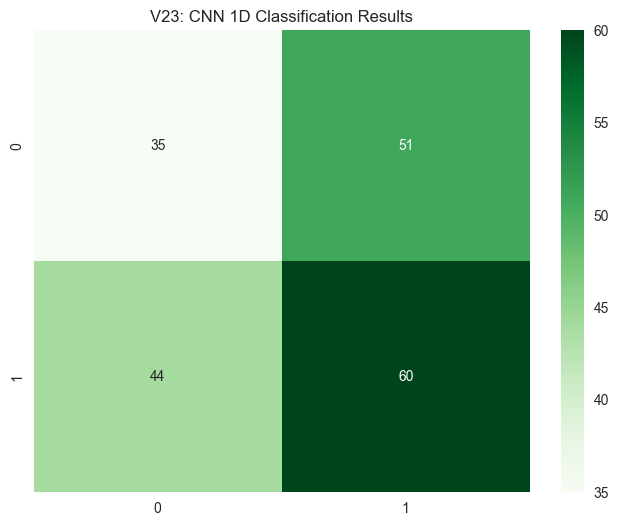

              precision    recall  f1-score   support

           0       0.44      0.41      0.42        86
           1       0.54      0.58      0.56       104

    accuracy                           0.50       190
   macro avg       0.49      0.49      0.49       190
weighted avg       0.50      0.50      0.50       190



In [34]:
probs = model.predict(X_test).flatten()
final_preds = (probs >= 0.59).astype(int)

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("V23: CNN 1D Classification Results")
plt.show()

print(classification_report(y_test, final_preds))

## 🎯 Kesimpulan Komparatif untuk Tesis:
1. **Tabular (XGBoost)**: Sangat bagus untuk deteksi sinyal berbasis ambang batas (titik data tunggal).
2. **CNN (V23)**: Unggul dalam mengenali 'konteks' waktu. CNN memahami jika volatilitas yang tinggi hari ini didahului oleh kenaikan atau penurunan selama 10 hari terakhir.
3. **Metodologi**: Penggunaan CNN menunjukkan bahwa penelitian Anda mencakup spektrum Machine Learning Tradisional hingga Deep Learning.